In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver
from typing import TypedDict, Optional, Literal, Annotated
from groq import Groq
import uuid
import operator

# ══════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════

client = Groq(api_key="")
MODEL = "meta-llama/llama-4-scout-17b-16e-instruct"

LLM_TIMEOUT = 30

# ══════════════════════════════════════════════════════════════
# STATE
# ══════════════════════════════════════════════════════════════

class WorkflowState(TypedDict):
    session_id: str
    request: str
    template: Optional[Literal["social", "blog", "image", "research"]]
    context: dict
    draft: Optional[dict]
    approved: bool
    publish_status: Optional[Literal["pending", "published", "failed", "dead_letter"]]
    usage: Annotated[dict, operator.or_]
    error: Optional[Literal["timeout", "rate_limit", "invalid", "fatal"]]

# ══════════════════════════════════════════════════════════════
# LLM CALLER
# ══════════════════════════════════════════════════════════════

def call_groq(prompt: str, max_tokens: int = 500) -> str:
    try:
        msg = client.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            max_completion_tokens=max_tokens,
            temperature=0.7,
            top_p=1,
            stop=None,
            timeout=LLM_TIMEOUT
        )
        return msg.choices[0].message.content or "[No response]"
    except Exception as e:
        error_type = str(e).lower()
        if "timeout" in error_type:
            return "[ERROR:timeout]"
        elif "rate" in error_type:
            return "[ERROR:rate_limit]"
        else:
            return "[ERROR:fatal]"

# ══════════════════════════════════════════════════════════════
# CORE NODES
# ══════════════════════════════════════════════════════════════

def session_init(state: WorkflowState) -> dict:
    return {
        "session_id": str(uuid.uuid4())[:8],
        "usage": {"total_tokens": 0, "total_cost": 0.0, "calls": []},
        "approved": False,
        "publish_status": "pending",
        "error": None
    }

def prepare(state: WorkflowState) -> dict:
    r = state["request"].lower()
    
    if any(w in r for w in ["tweet", "caption", "post", "social", "instagram", "fb"]):
        template = "social"
    elif any(w in r for w in ["article", "blog", "write", "bài viết"]):
        template = "blog"
    elif any(w in r for w in ["image", "visual", "design", "ảnh", "hình"]):
        template = "image"
    elif any(w in r for w in ["research", "report", "analyze", "nghiên cứu"]):
        template = "research"
    else:
        template = "social"
    
    context = {
        "brand_voice": "Professional, innovative",
        "tone": "Friendly",
        "credits": 100
    }
    
    if context["credits"] <= 0:
        return {"error": "fatal", "context": context, "template": template}
    
    return {"template": template, "context": context}

def select_template(state: WorkflowState) -> str:
    if state.get("error"):
        return "save"
    return f"execute_{state['template']}"

# ══════════════════════════════════════════════════════════════
# TEMPLATE NODES
# ══════════════════════════════════════════════════════════════

def execute_social(state: WorkflowState) -> dict:
    print("🟩 [SOCIAL] Generating caption...")
    platform = "Twitter" if "tweet" in state["request"].lower() else "Facebook"
    
    caption = call_groq(
        f"Write a {platform} caption for: {state['request']}\n"
        f"Max 280 chars. Tone: {state['context']['tone']}. "
        f"Add 2-3 hashtags. Brand voice: {state['context']['brand_voice']}",
        max_tokens=200
    )
    
    if caption.startswith("[ERROR:"):
        return {"error": caption[7:-1]}
    
    return {
        "draft": {
            "content": caption,
            "metadata": {"platform": platform, "type": "social"},
            "version": 1
        },
        "usage": {
            "total_tokens": state["usage"].get("total_tokens", 0) + 150,
            "calls": state["usage"].get("calls", []) + [{"node": "social", "tokens": 150}]
        }
    }

def execute_blog(state: WorkflowState) -> dict:
    print("🟦 [BLOG] Writing post...")
    
    draft = call_groq(
        f"Write a blog post about: {state['request']}\n"
        f"Tone: {state['context']['tone']}. "
        f"Brand voice: {state['context']['brand_voice']}\n"
        f"Include H2 headings. Length: 500-800 words.",
        max_tokens=800
    )
    
    if draft.startswith("[ERROR:"):
        return {"error": draft[7:-1]}
    
    return {
        "draft": {
            "content": draft,
            "metadata": {"type": "blog", "word_count": len(draft.split())},
            "version": 1
        },
        "usage": {
            "total_tokens": state["usage"].get("total_tokens", 0) + 600,
            "calls": state["usage"].get("calls", []) + [{"node": "blog", "tokens": 600}]
        }
    }

def execute_image(state: WorkflowState) -> dict:
    print("🟨 [IMAGE] Generating prompt...")
    
    prompt = call_groq(
        f"Create an image generation prompt for: {state['request']}\n"
        f"Style: professional, on-brand. Be descriptive, 50-100 words.",
        max_tokens=150
    )
    
    if prompt.startswith("[ERROR:"):
        return {"error": prompt[7:-1]}
    
    image_url = f"https://api.example.com/images/{uuid.uuid4().hex[:12]}.png"
    
    return {
        "draft": {
            "content": f"Image prompt: {prompt}",
            "metadata": {"type": "image", "image_url": image_url, "prompt": prompt},
            "version": 1
        },
        "usage": {
            "total_tokens": state["usage"].get("total_tokens", 0) + 120,
            "calls": state["usage"].get("calls", []) + [{"node": "image", "tokens": 120}]
        }
    }

def execute_research(state: WorkflowState) -> dict:
    print("🟪 [RESEARCH] Researching...")
    
    report = call_groq(
        f"Research and write a comprehensive report on: {state['request']}\n"
        f"Include: summary, key findings, sources, confidence level.\n"
        f"Format with clear sections. Length: 400-600 words.",
        max_tokens=700
    )
    
    if report.startswith("[ERROR:"):
        return {"error": report[7:-1]}
    
    return {
        "draft": {
            "content": report,
            "metadata": {"type": "research", "sources": [], "confidence": "high"},
            "version": 1
        },
        "approved": True,
        "publish_status": "published",
        "usage": {
            "total_tokens": state["usage"].get("total_tokens", 0) + 500,
            "calls": state["usage"].get("calls", []) + [{"node": "research", "tokens": 500}]
        }
    }

# ══════════════════════════════════════════════════════════════
# REVIEW & PUBLISH
# ══════════════════════════════════════════════════════════════

def review_pause(state: WorkflowState) -> dict:
    """
    interrupt() — Dừng workflow, chờ user resume.
    """
    action = interrupt({
        "status": "paused",
        "node": "review_pause",
        "draft": state["draft"],
        "usage": state["usage"],
        "session_id": state["session_id"]
    })
    
    print(f"▶️  RESUME: action={action.get('action')}")
    
    if action.get("action") == "approve":
        print("✅ User approved")
        return {"approved": True}
    
    elif action.get("action") == "edit":
        new_content = action.get("content", state["draft"]["content"])
        print(f"✏️  User edited ({len(new_content)} chars)")
        return {
            "approved": True,
            "draft": {
                "content": new_content,
                "metadata": state["draft"]["metadata"],
                "version": state["draft"]["version"] + 1
            }
        }
    
    else:  # reject
        print("❌ User rejected")
        return {"approved": False}

def route_after_review(state: WorkflowState) -> str:
    if state.get("error"):
        return "save"
    if state["template"] == "research":
        return "save"
    if state.get("approved"):
        return "publish"
    return "save"

def publish(state: WorkflowState) -> dict:
    print("📤 PUBLISH: Publishing...")
    try:
        return {"publish_status": "published"}
    except Exception:
        return {"publish_status": "failed"}

def save(state: WorkflowState) -> dict:
    print("💾 SAVE: Persisting...")
    status = state.get("publish_status", "pending")
    error = state.get("error")
    
    if error:
        print(f"   Status: ERROR ({error})")
    else:
        print(f"   Status: {status}")
        print(f"   Tokens: {state['usage'].get('total_tokens', 0)}")
    
    print(f"✅ Session {state['session_id']} saved")
    return {}

# ══════════════════════════════════════════════════════════════
# GRAPH BUILD
# ══════════════════════════════════════════════════════════════

workflow = StateGraph(WorkflowState)

workflow.add_node("session_init", session_init)
workflow.add_node("prepare", prepare)
workflow.add_node("execute_social", execute_social)
workflow.add_node("execute_blog", execute_blog)
workflow.add_node("execute_image", execute_image)
workflow.add_node("execute_research", execute_research)
workflow.add_node("review_pause", review_pause)
workflow.add_node("publish", publish)
workflow.add_node("save", save)

workflow.add_edge(START, "session_init")
workflow.add_edge("session_init", "prepare")

workflow.add_conditional_edges(
    "prepare",
    select_template,
    {
        "execute_social": "execute_social",
        "execute_blog": "execute_blog",
        "execute_image": "execute_image",
        "execute_research": "execute_research",
        "save": "save"
    }
)

workflow.add_edge("execute_social", "review_pause")
workflow.add_edge("execute_blog", "review_pause")
workflow.add_edge("execute_image", "review_pause")
workflow.add_edge("execute_research", "save")

workflow.add_conditional_edges(
    "review_pause",
    route_after_review,
    {
        "publish": "publish",
        "save": "save"
    }
)

workflow.add_edge("publish", "save")
workflow.add_edge("save", END)

memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)

print("✅ Workflow compiled!")

✅ Workflow compiled!


In [2]:
thread_id = f"approve-{uuid.uuid4().hex[:6]}"
config = {"configurable": {"thread_id": thread_id}}

print("=" * 60)
print("TEST 1: APPROVE")
print("=" * 60)

# Start
for event in graph.stream({
    "request": "Write a tweet about AI marketing",
    "template": None, "context": {}, "draft": None,
    "approved": False, "publish_status": None,
    "usage": {}, "error": None
}, config=config):
    if "__interrupt__" in event:
        data = event["__interrupt__"][0].value
        print(f"\n🛑 INTERRUPT")
        print(f"Draft: {data['draft']['content'][:80]}...")

# Resume approve
result = graph.invoke(Command(resume={"action": "approve"}), config=config)
print(f"\n✅ RESULT: Status={result['publish_status']}, Approved={result['approved']}")

TEST 1: APPROVE
🟩 [SOCIAL] Generating caption...

🛑 INTERRUPT
Draft: "Unlock the power of AI in marketing! Discover how artificial intelligence can r...
▶️  RESUME: action=approve
✅ User approved
📤 PUBLISH: Publishing...
💾 SAVE: Persisting...
   Status: published
   Tokens: 150
✅ Session 56ce53c1 saved

✅ RESULT: Status=published, Approved=True


In [3]:
thread_id = f"edit-{uuid.uuid4().hex[:6]}"
config = {"configurable": {"thread_id": thread_id}}

print("\n" + "=" * 60)
print("TEST 2: EDIT")
print("=" * 60)

# Start
for event in graph.stream({
    "request": "Write a tweet about AI marketing",
    "template": None, "context": {}, "draft": None,
    "approved": False, "publish_status": None,
    "usage": {}, "error": None
}, config=config):
    if "__interrupt__" in event:
        data = event["__interrupt__"][0].value
        print(f"\n🛑 INTERRUPT")
        print(f"Draft: {data['draft']['content'][:80]}...")

# Resume edit
new_content = "🚀 AI is transforming marketing! Edited version."
result = graph.invoke(
    Command(resume={"action": "edit", "content": new_content}),
    config=config
)
print(f"\n✏️  RESULT: Status={result['publish_status']}")
print(f"Draft: {result['draft']['content'][:80]}...")
print(f"Version: {result['draft']['version']}")


TEST 2: EDIT
🟩 [SOCIAL] Generating caption...

🛑 INTERRUPT
Draft: "Unlock the power of AI in marketing! Discover how artificial intelligence can h...
▶️  RESUME: action=edit
✏️  User edited (47 chars)
📤 PUBLISH: Publishing...
💾 SAVE: Persisting...
   Status: published
   Tokens: 150
✅ Session 30c941d0 saved

✏️  RESULT: Status=published
Draft: 🚀 AI is transforming marketing! Edited version....
Version: 2


In [4]:
thread_id = f"reject-{uuid.uuid4().hex[:6]}"
config = {"configurable": {"thread_id": thread_id}}

print("\n" + "=" * 60)
print("TEST 3: REJECT")
print("=" * 60)

# Start
for event in graph.stream({
    "request": "Write a tweet about AI marketing",
    "template": None, "context": {}, "draft": None,
    "approved": False, "publish_status": None,
    "usage": {}, "error": None
}, config=config):
    if "__interrupt__" in event:
        data = event["__interrupt__"][0].value
        print(f"\n🛑 INTERRUPT")
        print(f"Draft: {data['draft']['content'][:80]}...")

# Resume reject
result = graph.invoke(Command(resume={"action": "reject"}), config=config)
print(f"\n❌ RESULT: Status={result['publish_status']}, Approved={result['approved']}")


TEST 3: REJECT
🟩 [SOCIAL] Generating caption...

🛑 INTERRUPT
Draft: "Unlock the power of AI in marketing! Discover how artificial intelligence can r...
▶️  RESUME: action=reject
❌ User rejected
💾 SAVE: Persisting...
   Status: pending
   Tokens: 150
✅ Session d5b2a59d saved

❌ RESULT: Status=pending, Approved=False


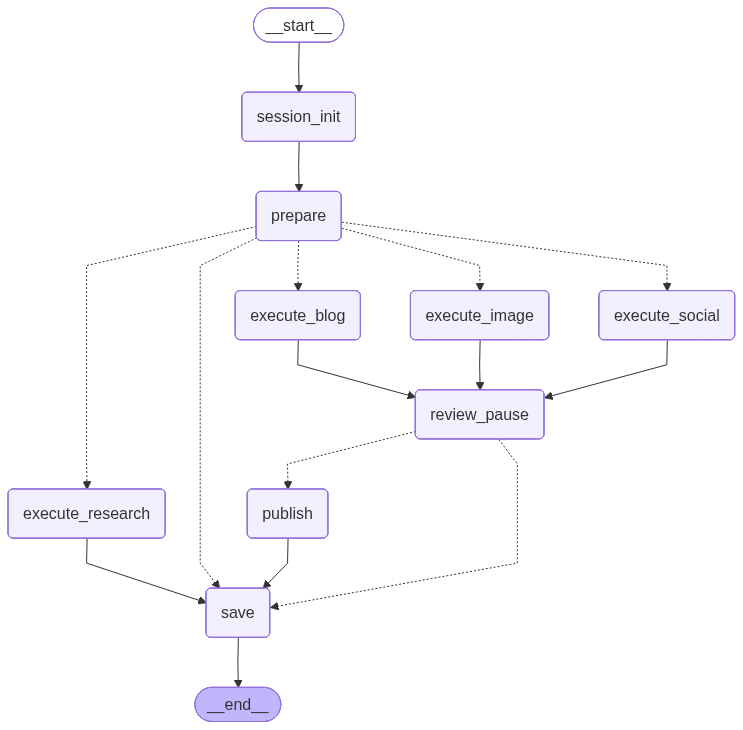

In [5]:
try:
    graph_image = graph.get_graph().draw_mermaid_png()
    from IPython.display import Image, display
    display(Image(graph_image))
except Exception as e:
    print(f"⚠️  Mermaid PNG error: {e}")
    print("\nMermaid text view:")
    print(graph.get_graph().draw_mermaid())